Import libraries

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
#رسم المخططات والرسوم البيانية
import seaborn as sns 
#رسوم بيانات احصائيه



Load Dataset


In [144]:
dataset = pd.read_csv('C:\\Users\\heban\\Downloads\\DS230-Final-project-Winter2026--main\\DS230-Final-project-Winter2026--main\\DS230 Final project (Winter2026)\\OnlineNewsPopularity\\OnlineNewsPopularity.csv')

Display Basic Information

In [146]:
# اول خمس صفوف من البيانات 
print (dataset.head())
#عدد الصفوف والأعمدة
print (dataset.shape)
#أسماء الأعمدة
print (dataset.columns)
#أنواع البيانات 
dataset.info()




                                                 url   timedelta  \
0  http://mashable.com/2013/01/07/amazon-instant-...       731.0   
1  http://mashable.com/2013/01/07/ap-samsung-spon...       731.0   
2  http://mashable.com/2013/01/07/apple-40-billio...       731.0   
3  http://mashable.com/2013/01/07/astronaut-notre...       731.0   
4   http://mashable.com/2013/01/07/att-u-verse-apps/       731.0   

    n_tokens_title   n_tokens_content   n_unique_tokens   n_non_stop_words  \
0             12.0              219.0          0.663594                1.0   
1              9.0              255.0          0.604743                1.0   
2              9.0              211.0          0.575130                1.0   
3              9.0              531.0          0.503788                1.0   
4             13.0             1072.0          0.415646                1.0   

    n_non_stop_unique_tokens   num_hrefs   num_self_hrefs   num_imgs  \
0                   0.815385         4.0          

Statistical Summary

In [174]:
print(dataset.describe())   # للأرقام 
print(dataset.describe(include='object')) #للنصوص 

          timedelta  n_tokens_title  n_tokens_content  n_unique_tokens  \
count  39644.000000    39644.000000      39644.000000     39644.000000   
mean     354.530471       10.398749        546.514731         0.548216   
std      214.163767        2.114037        471.107508         3.520708   
min        8.000000        2.000000          0.000000         0.000000   
25%      164.000000        9.000000        246.000000         0.470870   
50%      339.000000       10.000000        409.000000         0.539226   
75%      542.000000       12.000000        716.000000         0.608696   
max      731.000000       23.000000       8474.000000       701.000000   

       n_non_stop_words  n_non_stop_unique_tokens     num_hrefs  \
count      39644.000000              39644.000000  39644.000000   
mean           0.996469                  0.689175     10.883690   
std            5.231231                  3.264816     11.332017   
min            0.000000                  0.000000      0.000000  

C:\Users\heban\AppData\Local\Temp\ipykernel_21372\3371936194.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(dataset.describe(include='object')) #للنصوص


Missing Values Analysis

Missing data in each column:
 url                             0
timedelta                       0
n_tokens_title                  0
n_tokens_content                0
n_unique_tokens                 0
                               ..
title_subjectivity              0
title_sentiment_polarity        0
abs_title_subjectivity          0
abs_title_sentiment_polarity    0
shares                          0
Length: 61, dtype: int64
url                             0.0
timedelta                       0.0
n_tokens_title                  0.0
n_tokens_content                0.0
n_unique_tokens                 0.0
                               ... 
title_subjectivity              0.0
title_sentiment_polarity        0.0
abs_title_subjectivity          0.0
abs_title_sentiment_polarity    0.0
shares                          0.0
Length: 61, dtype: float64


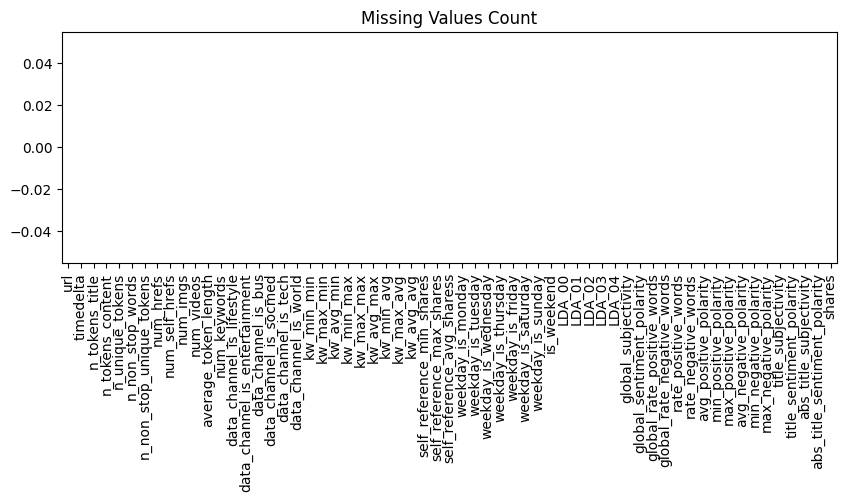

In [175]:
missing_data =dataset.isnull().sum()
print("Missing data in each column:\n",missing_data)
missing = dataset.isnull().mean()*100
print(missing.sort_values(ascending=False))
#visualize missing data
plt.figure(figsize=(10,3))
missing_data.plot( kind='bar')
plt.title('Missing Values Count')
plt.show()

#No missing values were found in the dataset.#

Duplicate Analysis

In [176]:
dataset.duplicated().sum()

np.int64(0)

#No duplicate rows were found in the dataset.
No action is required.#

Target Variable Analysis

In [177]:
print(dataset.columns)
dataset.columns = dataset.columns.str.strip()
#Extra spaces were detected in column names and removed before continuing the analysis.

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [178]:
dataset["shares"].describe()

count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64

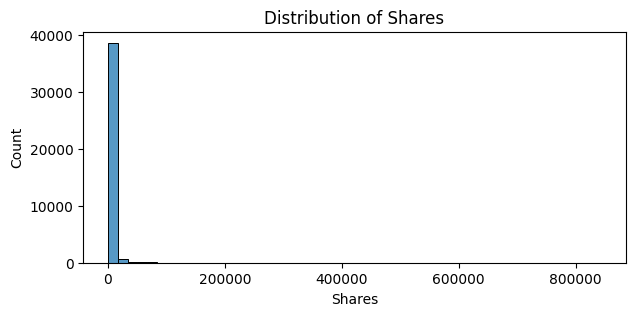

In [179]:
#Histogram
plt.figure(figsize=(7,3))
sns.histplot(dataset["shares"],bins=50)
plt.title("Distribution of Shares")
plt.xlabel("Shares")
plt.show()

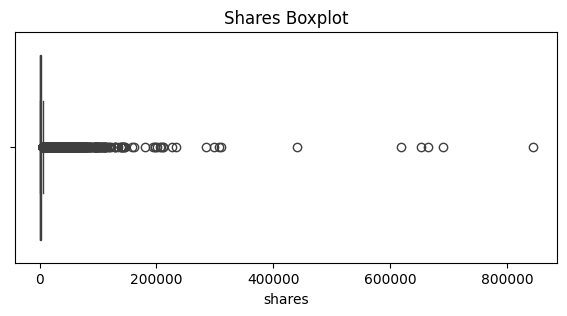

In [180]:
#Boxplot
plt.figure(figsize=(7,3))
sns.boxplot(x=dataset["shares"])
plt.title("Shares Boxplot")
plt.show()

In [181]:
#Skewness
dataset["shares"].skew()

np.float64(33.963884875714164)

#Highly Right-Skewed.
The target variable (shares) is highly right-skewed and contains significant outliers.#

Numerical Features Analysis

In [182]:
num_cols = dataset.select_dtypes( include=np.number)
num_cols.columns

Index(['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
       'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
       'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
       'glob

In [183]:
print(len(num_cols.columns))

60


In [184]:
num_cols.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,4.548239,7.223767,0.052946,0.178009,0.157855,0.058597,0.185299,0.212567,26.106801,1153.951682,312.366967,13612.354102,752324.066694,259281.938083,1117.146610,5657.211151,3135.858639,3998.755396,10329.212662,6401.697580,0.168020,0.186409,0.187544,0.183306,0.143805,0.061876,0.069039,0.130915,0.184599,0.141256,0.216321,0.223770,0.234029,0.443370,0.119309,0.039625,0.016612,0.682150,0.287934,0.353825,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,0.844406,1.909130,0.223929,0.382525,0.364610,0.234871,0.388545,0.409129,69.633215,3857.990877,620.783887,57986.029357,214502.129573,135102.247285,1137.456951,6098.871957,1318.150397,19738.670516,41027.576613,24211.332231,0.373889,0.389441,0.390353,0.386922,0.350896,0.240933,0.253524,0.337312,0.262975,0.219707,0.282145,0.295191,0.289183,0.116685,0.096931,0.017429,0.010828,0.190206,0.156156,0.104542,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.393750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,4.478404,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,445.000000,141.750000,0.000000,843300.000000,172846.875000,0.000000,3562.101631,2382.448566,639.000000,1100.000000,981.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025051,0.025012,0.028571,0.028571,0.0

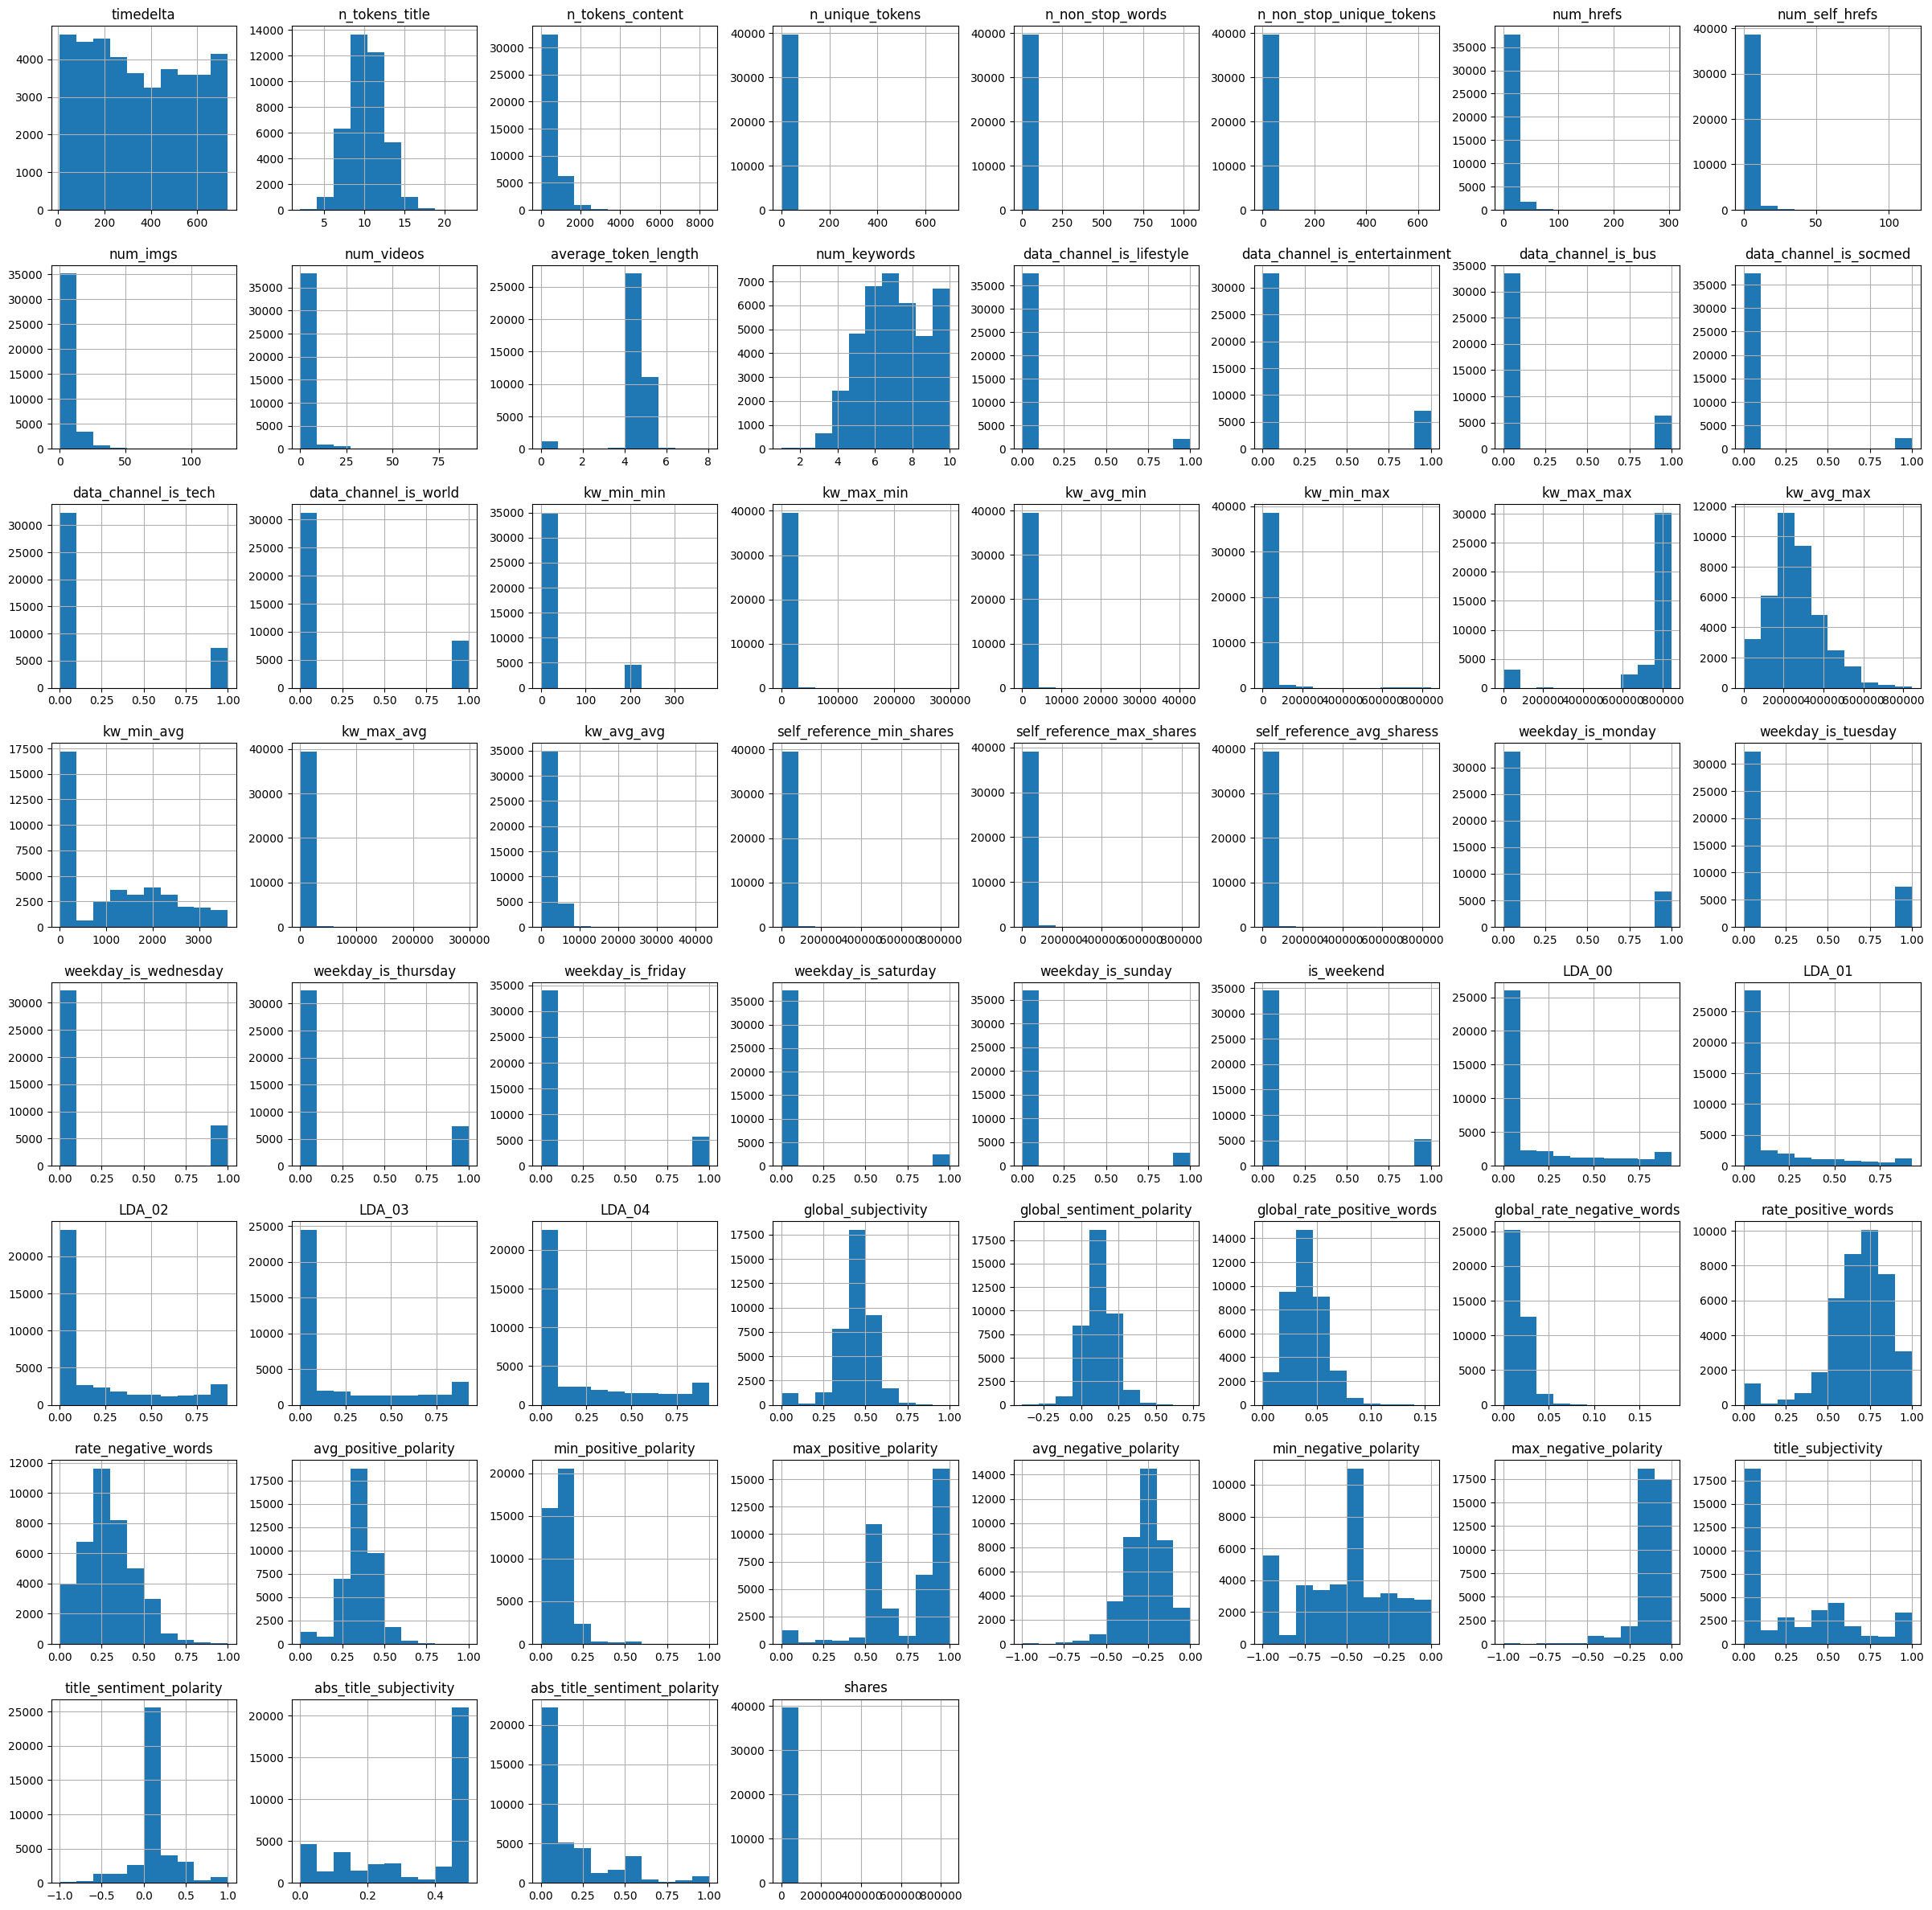

In [185]:
num_cols.hist(figsize=(30,30))
plt.show()
   

Outlier Detection

In [186]:
num_cols = dataset.select_dtypes(include="number")
print(num_cols)

       timedelta  n_tokens_title  n_tokens_content  n_unique_tokens  \
0          731.0            12.0             219.0         0.663594   
1          731.0             9.0             255.0         0.604743   
2          731.0             9.0             211.0         0.575130   
3          731.0             9.0             531.0         0.503788   
4          731.0            13.0            1072.0         0.415646   
...          ...             ...               ...              ...   
39639        8.0            11.0             346.0         0.529052   
39640        8.0            12.0             328.0         0.696296   
39641        8.0            10.0             442.0         0.516355   
39642        8.0             6.0             682.0         0.539493   
39643        8.0            10.0             157.0         0.701987   

       n_non_stop_words  n_non_stop_unique_tokens  num_hrefs  num_self_hrefs  \
0                   1.0                  0.815385        4.0       

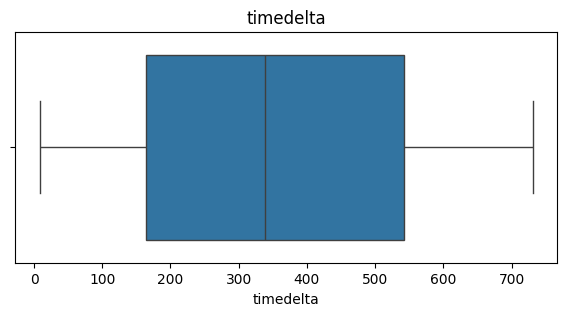

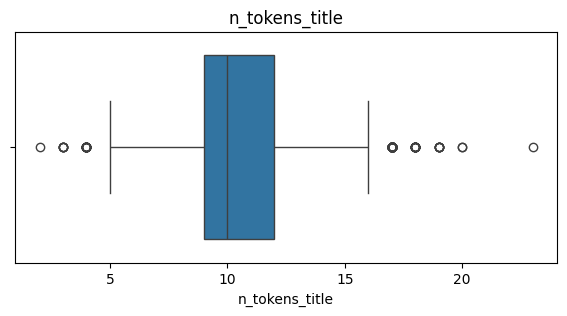

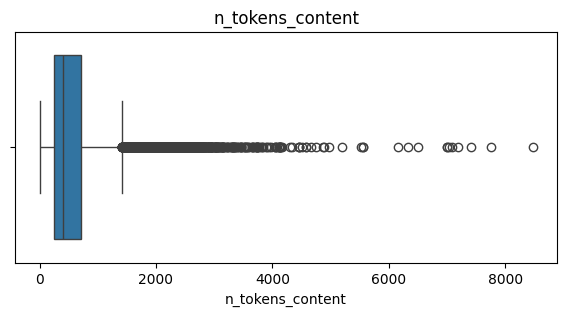

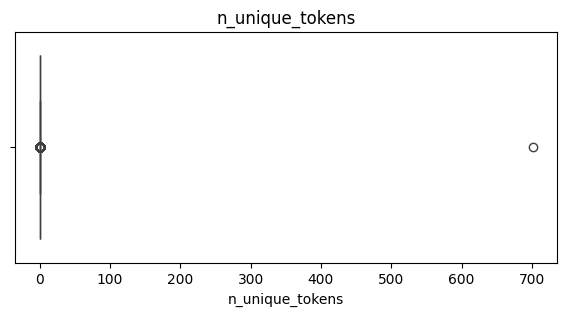

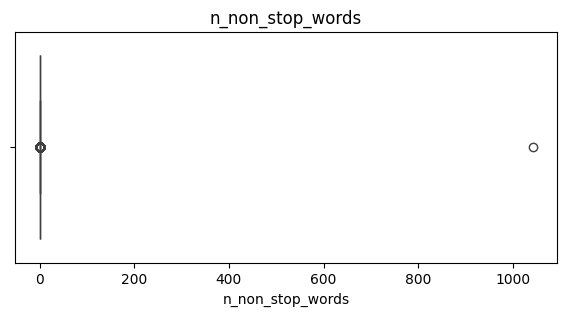

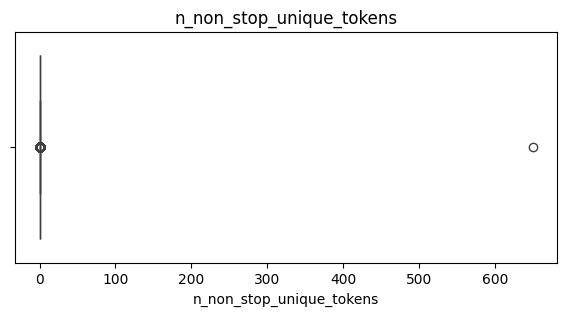

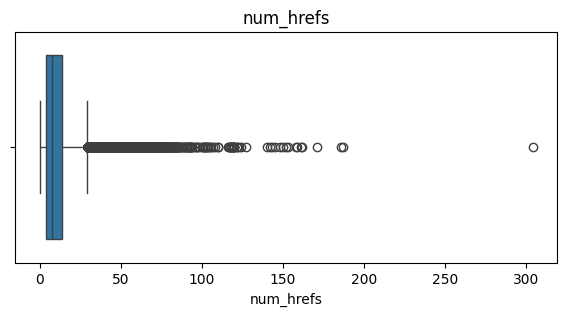

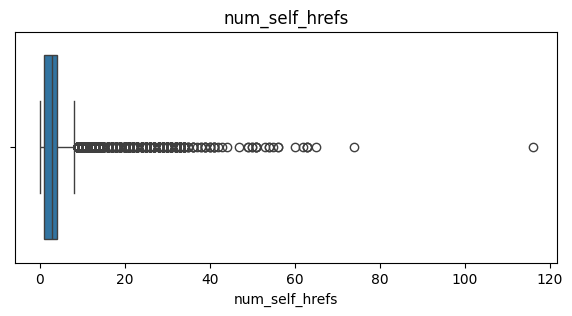

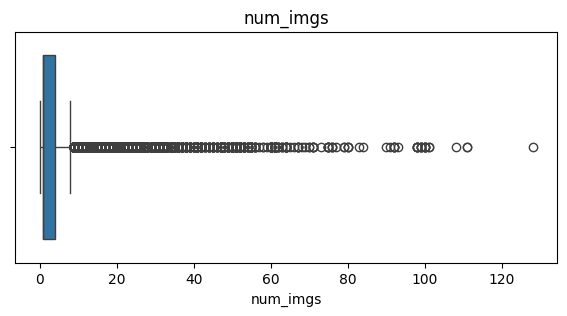

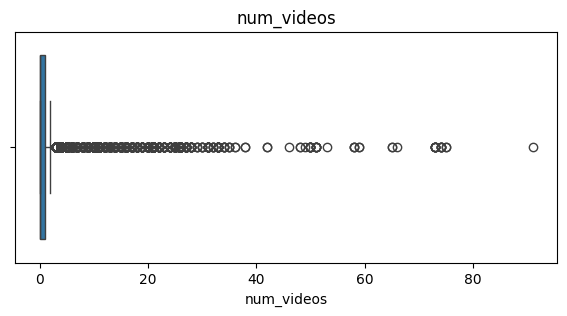

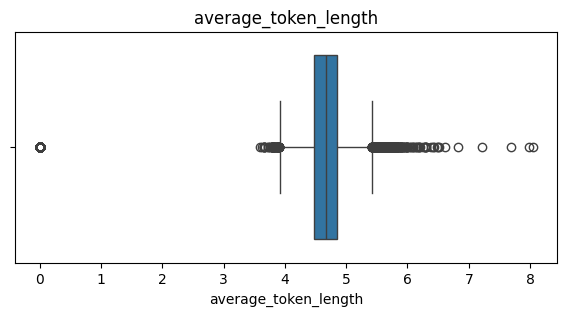

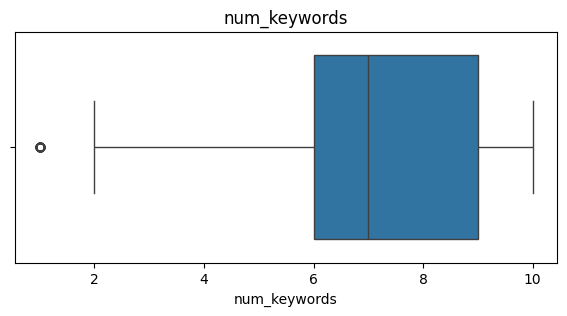

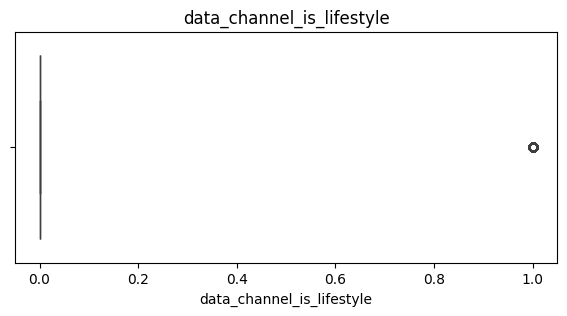

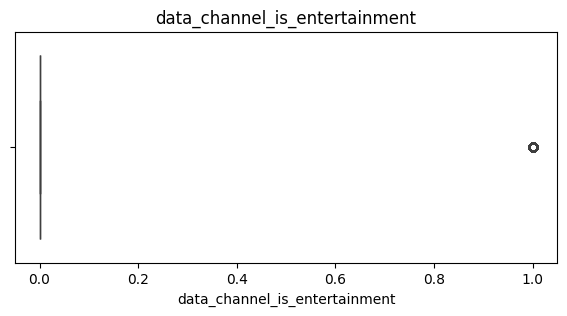

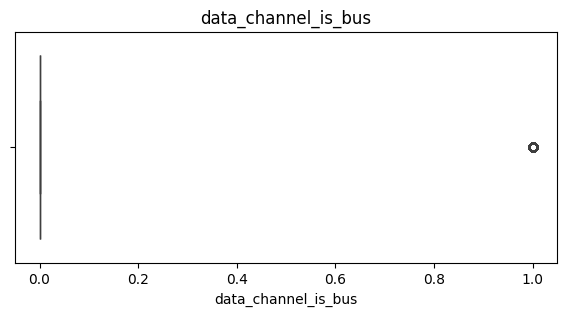

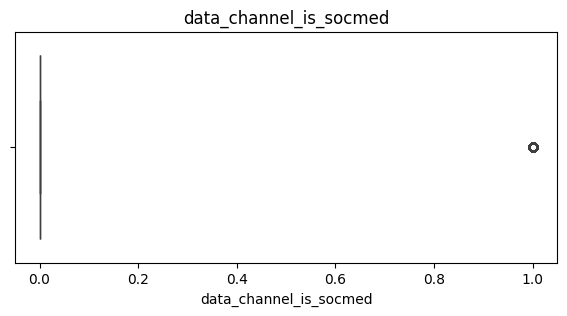

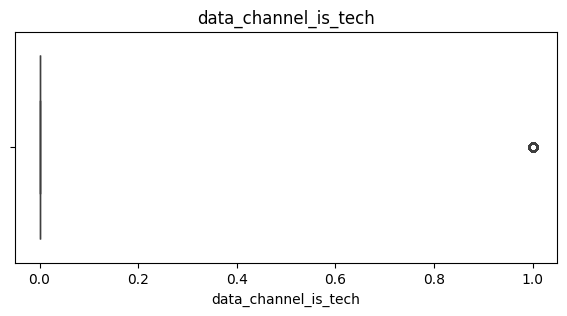

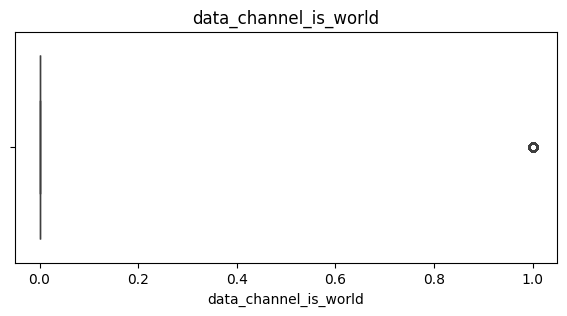

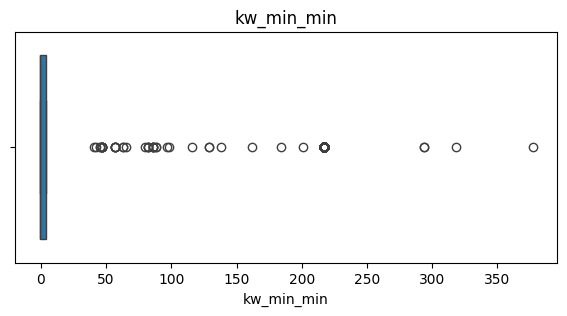

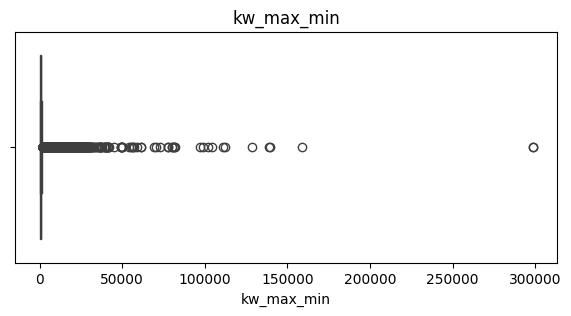

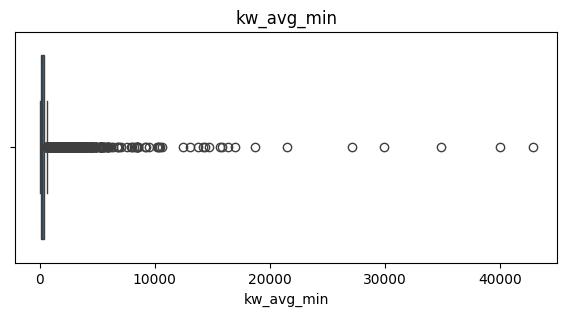

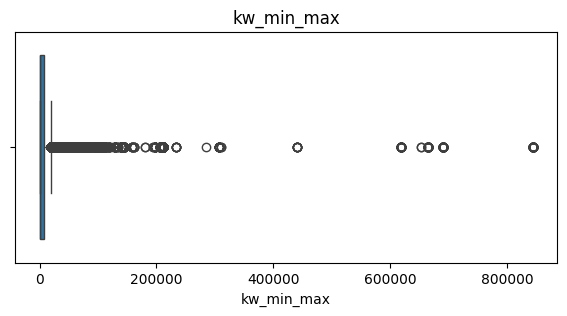

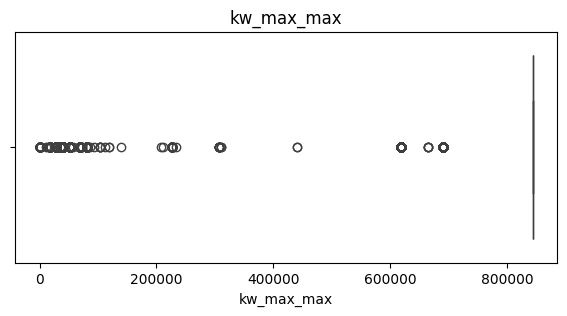

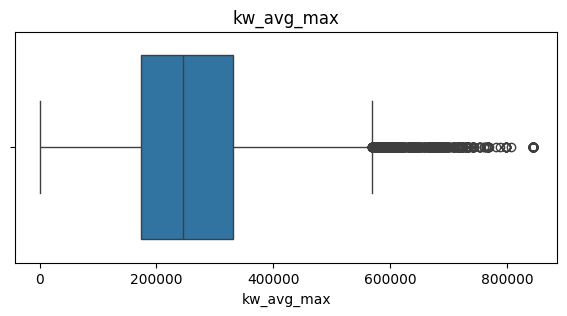

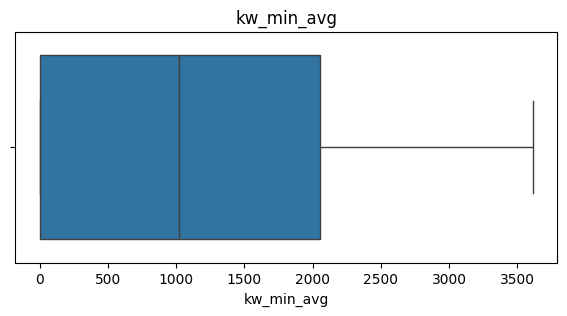

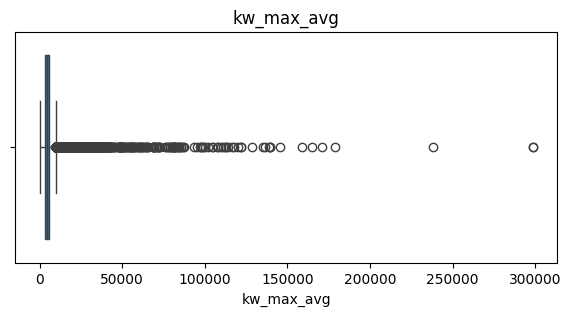

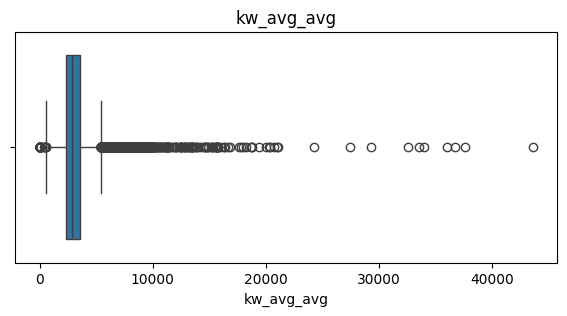

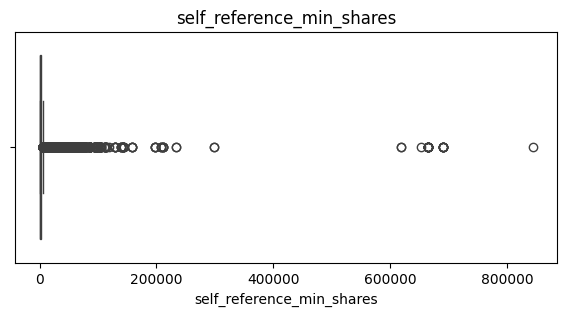

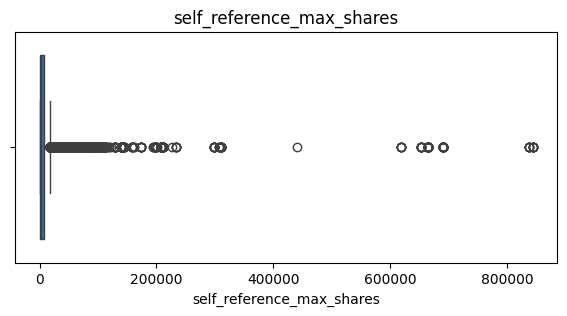

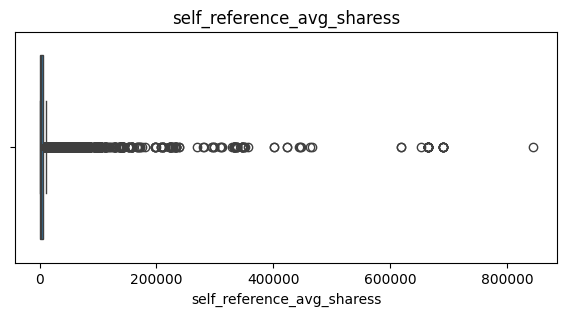

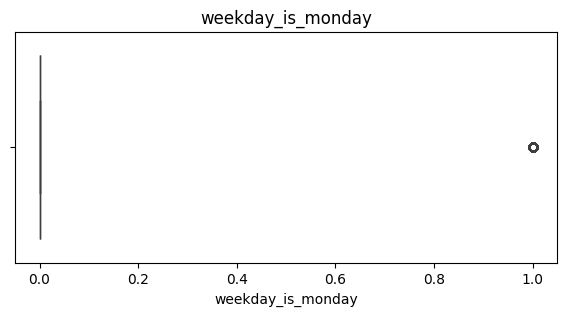

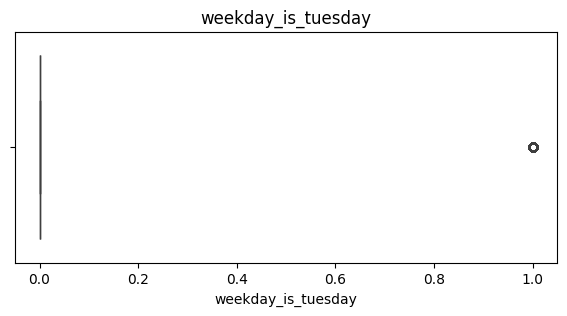

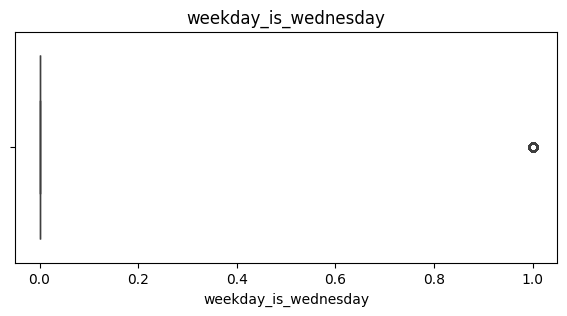

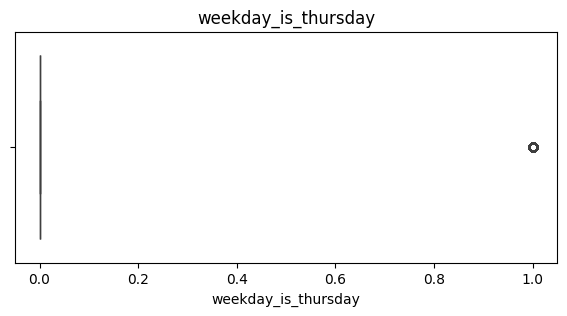

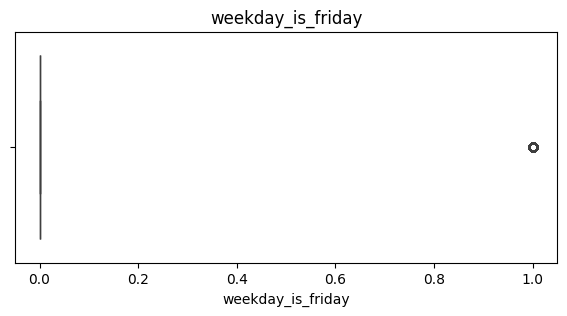

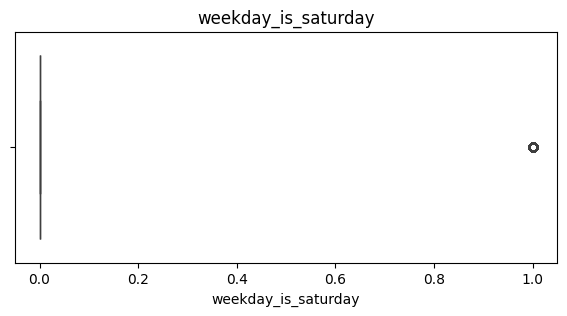

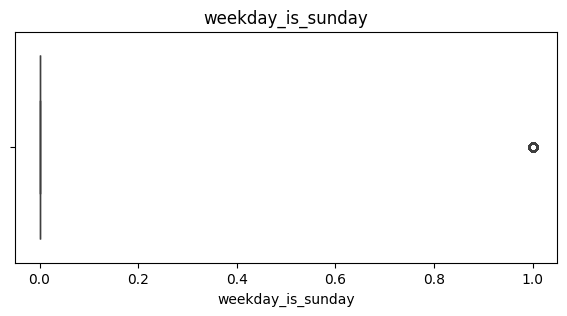

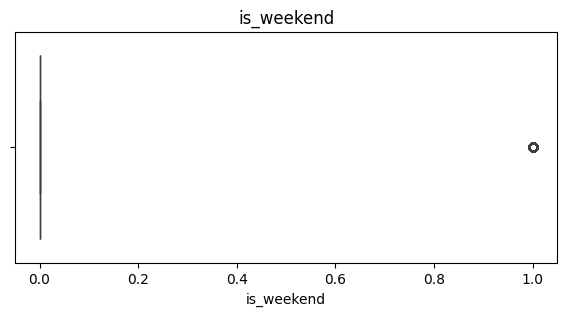

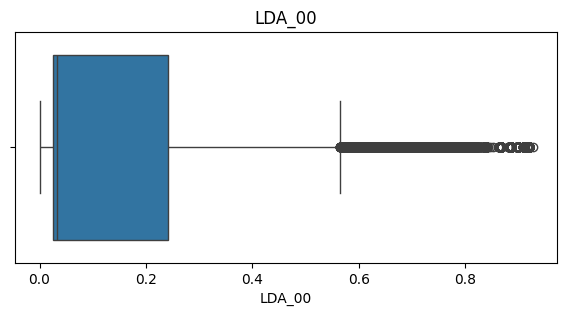

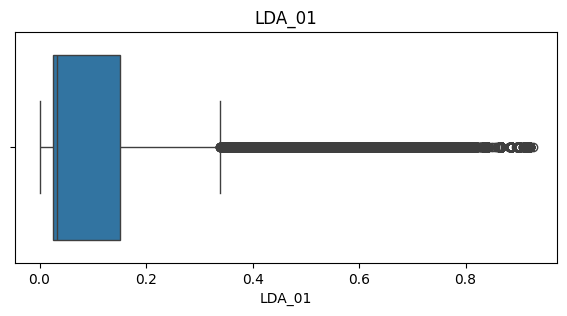

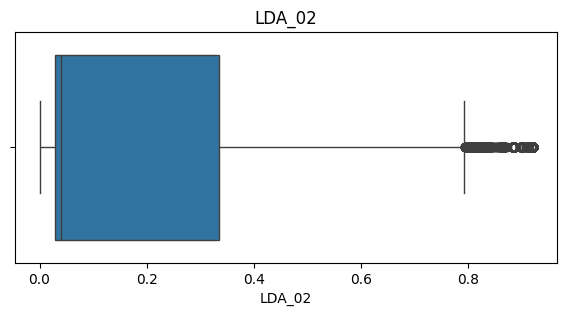

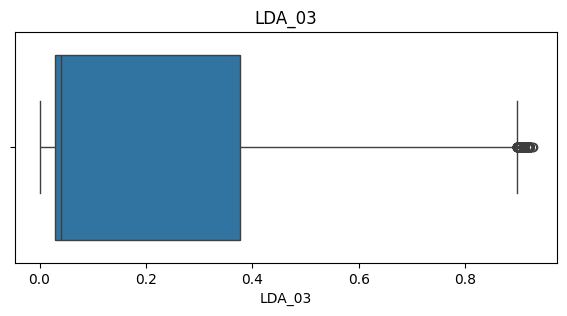

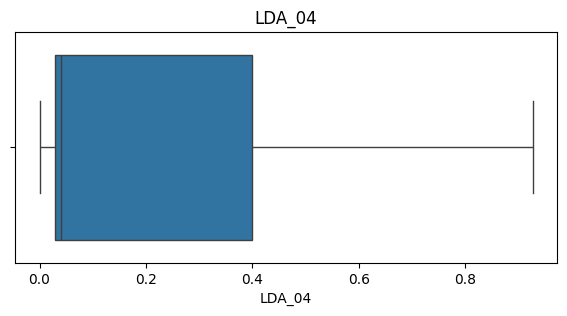

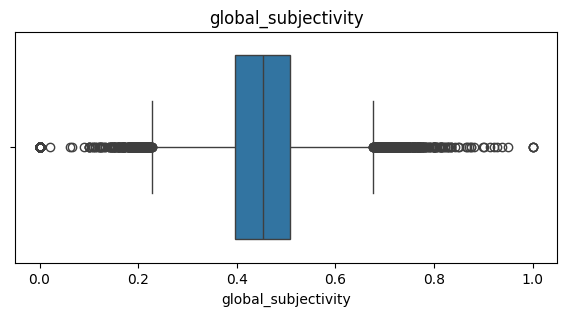

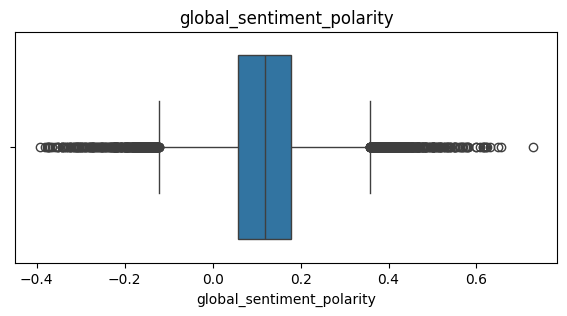

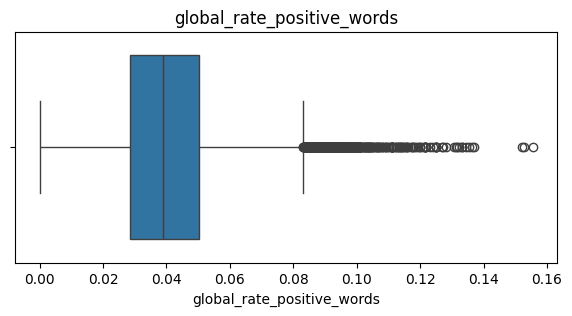

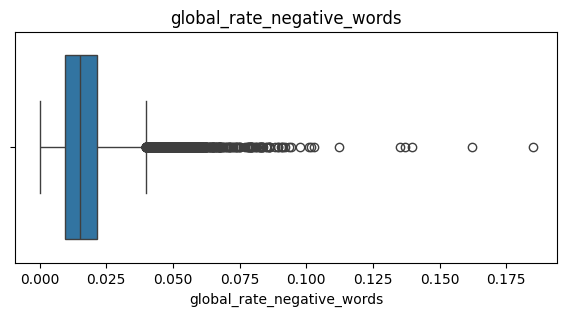

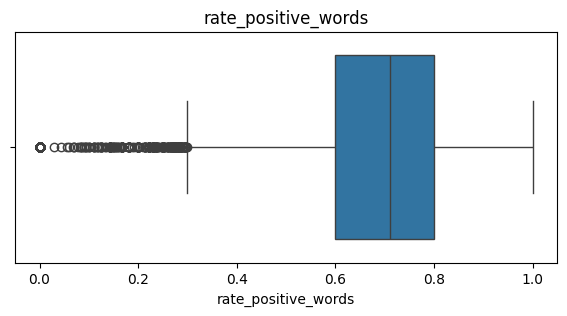

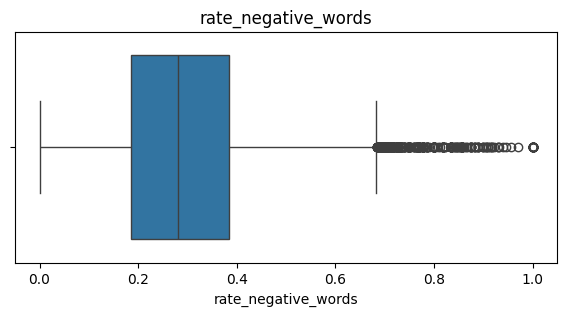

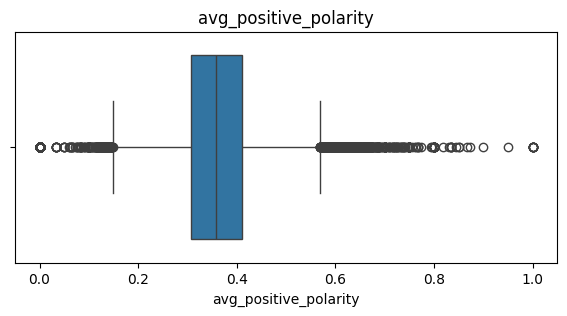

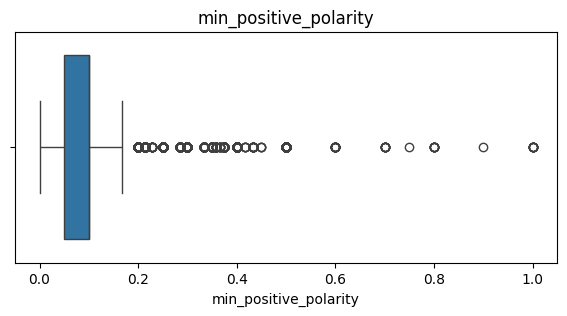

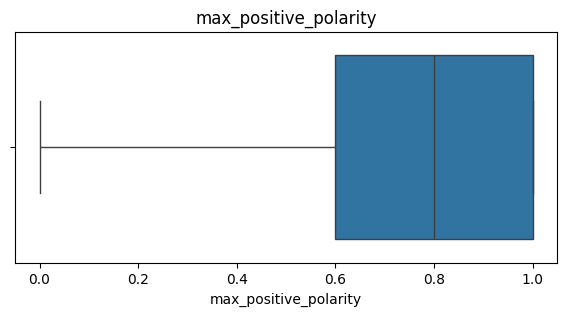

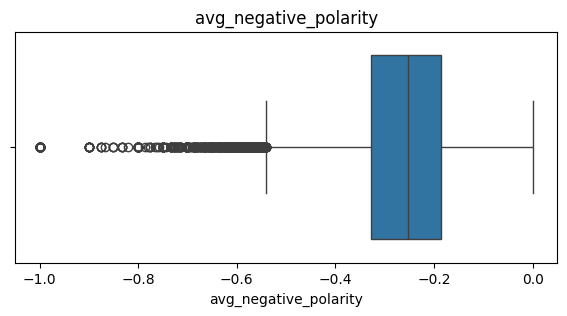

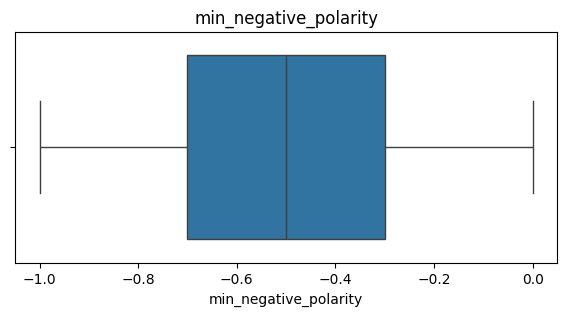

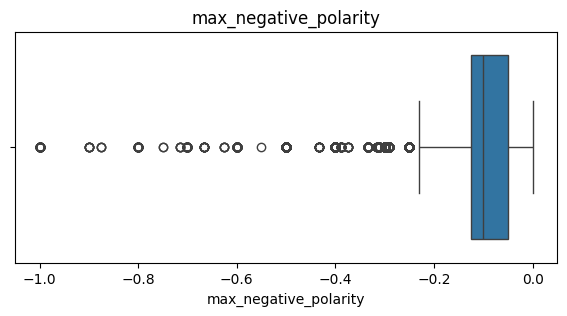

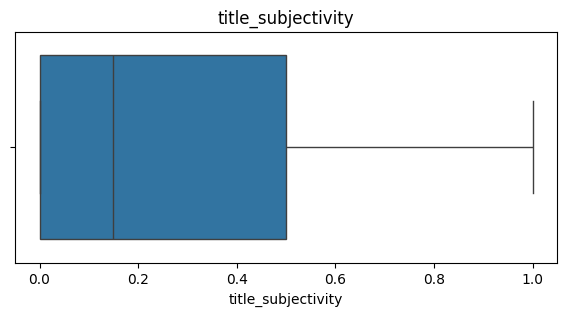

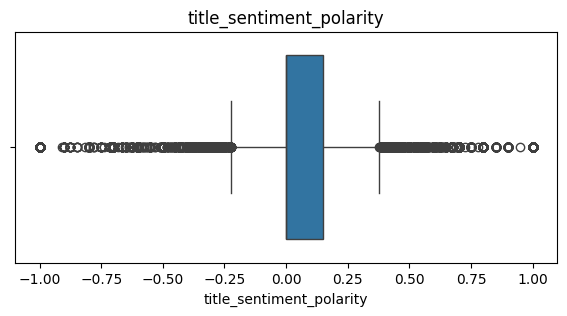

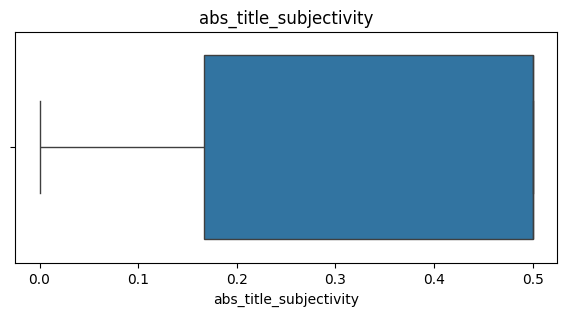

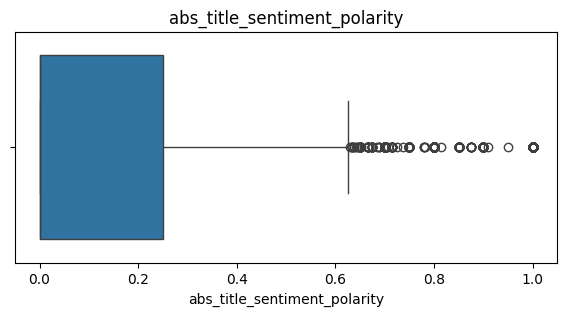

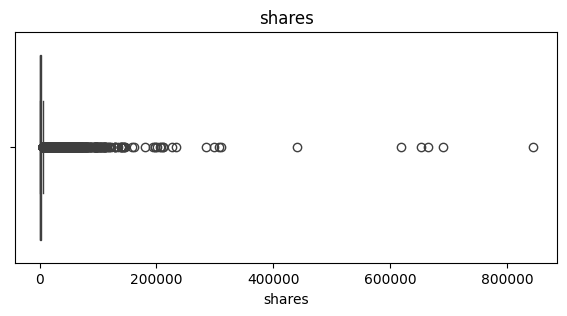

In [160]:
#Boxplots
for col in num_cols.columns:
    plt.figure( figsize=(7,3))
    sns.boxplot( x=dataset[col])
    plt.title(col)
    plt.show()

In [161]:
for col in num_cols.columns:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = (
        (dataset[col] <(Q1-1.5*IQR) )|(dataset[col]>(Q3+1.5*IQR))).sum()

    print( col,outliers)  

timedelta 0
n_tokens_title 156
n_tokens_content 1933
n_unique_tokens 1604
n_non_stop_words 2827
n_non_stop_unique_tokens 1733
num_hrefs 2169
num_self_hrefs 2090
num_imgs 7703
num_videos 2946
average_token_length 1681
num_keywords 51
data_channel_is_lifestyle 2099
data_channel_is_entertainment 7057
data_channel_is_bus 6258
data_channel_is_socmed 2323
data_channel_is_tech 7346
data_channel_is_world 8427
kw_min_min 4677
kw_max_min 3661
kw_avg_min 2081
kw_min_max 5063
kw_max_max 9440
kw_avg_max 960
kw_min_avg 0
kw_max_avg 2391
kw_avg_avg 1629
self_reference_min_shares 4976
self_reference_max_shares 4183
self_reference_avg_sharess 4209
weekday_is_monday 6661
weekday_is_tuesday 7390
weekday_is_wednesday 7435
weekday_is_thursday 7267
weekday_is_friday 5701
weekday_is_saturday 2453
weekday_is_sunday 2737
is_weekend 5190
LDA_00 5282
LDA_01 5834
LDA_02 3541
LDA_03 1075
LDA_04 0
global_subjectivity 1912
global_sentiment_polarity 825
global_rate_positive_words 497
global_rate_negative_words 1324
r

#Several numerical features contain outliers based on the boxplot visualization and IQR analysis. Outliers appear more noticeably in variables related to content, keywords, and the target variable (shares).#

Correlation Analysis

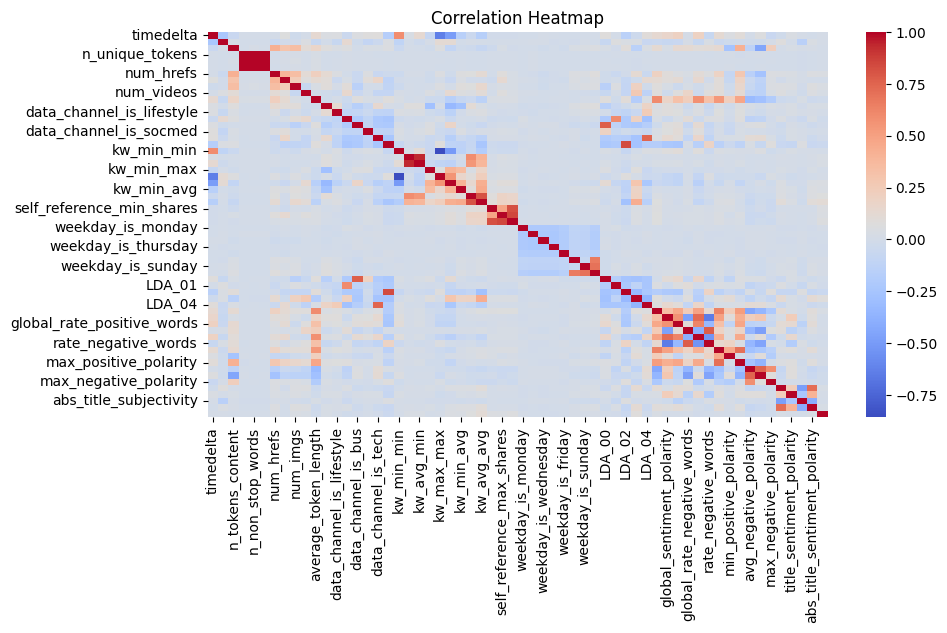

In [162]:
corr = dataset.corr( numeric_only=True)
#Heatmap
plt.figure( figsize=(10,5))
sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [163]:
corr["shares"]\
.sort_values(ascending=False)


shares                           1.000000
kw_avg_avg                       0.110413
LDA_03                           0.083771
kw_max_avg                       0.064306
self_reference_avg_sharess       0.057789
self_reference_min_shares        0.055958
self_reference_max_shares        0.047115
num_hrefs                        0.045404
kw_avg_max                       0.044686
kw_min_avg                       0.039551
num_imgs                         0.039388
global_subjectivity              0.031604
kw_avg_min                       0.030406
kw_max_min                       0.030114
abs_title_sentiment_polarity     0.027135
num_videos                       0.023936
title_subjectivity               0.021967
num_keywords                     0.021818
is_weekend                       0.016958
weekday_is_saturday              0.015082
title_sentiment_polarity         0.012772
avg_positive_polarity            0.012142
max_positive_polarity            0.010068
weekday_is_monday                0

In [164]:
corr["shares"]\
.sort_values(ascending=False)\
.head(10)

shares                        1.000000
kw_avg_avg                    0.110413
LDA_03                        0.083771
kw_max_avg                    0.064306
self_reference_avg_sharess    0.057789
self_reference_min_shares     0.055958
self_reference_max_shares     0.047115
num_hrefs                     0.045404
kw_avg_max                    0.044686
kw_min_avg                    0.039551
Name: shares, dtype: float64

In [165]:
corr["shares"]\
.sort_values(ascending=False)\
.head(10)

shares                        1.000000
kw_avg_avg                    0.110413
LDA_03                        0.083771
kw_max_avg                    0.064306
self_reference_avg_sharess    0.057789
self_reference_min_shares     0.055958
self_reference_max_shares     0.047115
num_hrefs                     0.045404
kw_avg_max                    0.044686
kw_min_avg                    0.039551
Name: shares, dtype: float64

#Most features have weak correlation with shares.
This indicates that prediction may rely on multiple features together.#

Features Correlated with Target

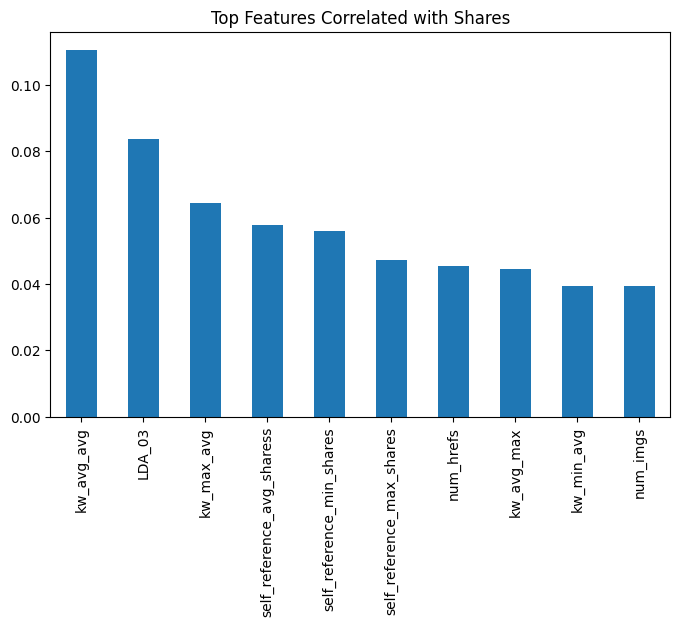

In [166]:
#Bar Chart
top_corr = (corr["shares"].sort_values(ascending=False)[1:11])
plt.figure(figsize=(8,5))
top_corr.plot(kind="bar")
plt.title("Top Features Correlated with Shares")
plt.show()

#The most correlated features show relatively weak relationships with shares.
Multiple features may contribute to prediction performance.#

Categorical Features Analysis

In [167]:
cat_cols = dataset.select_dtypes(include="object")
cat_cols.columns

C:\Users\heban\AppData\Local\Temp\ipykernel_21372\3776634926.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dataset.select_dtypes(include="object")


Index(['url'], dtype='str')

In [168]:
for col in cat_cols.columns:
    print( dataset[col].value_counts())
  

url
http://mashable.com/2013/01/07/amazon-instant-video-browser/                             1
http://mashable.com/2013/01/07/ap-samsung-sponsored-tweets/                              1
http://mashable.com/2013/01/07/apple-40-billion-app-downloads/                           1
http://mashable.com/2013/01/07/astronaut-notre-dame-bcs/                                 1
http://mashable.com/2013/01/07/att-u-verse-apps/                                         1
                                                                                        ..
http://mashable.com/2014/12/27/samsung-app-autism/                                       1
http://mashable.com/2014/12/27/seth-rogen-james-franco-will-live-tweet-the-interview/    1
http://mashable.com/2014/12/27/son-pays-off-mortgage/                                    1
http://mashable.com/2014/12/27/ukraine-blasts/                                           1
http://mashable.com/2014/12/27/youtube-channels-2015/                                 

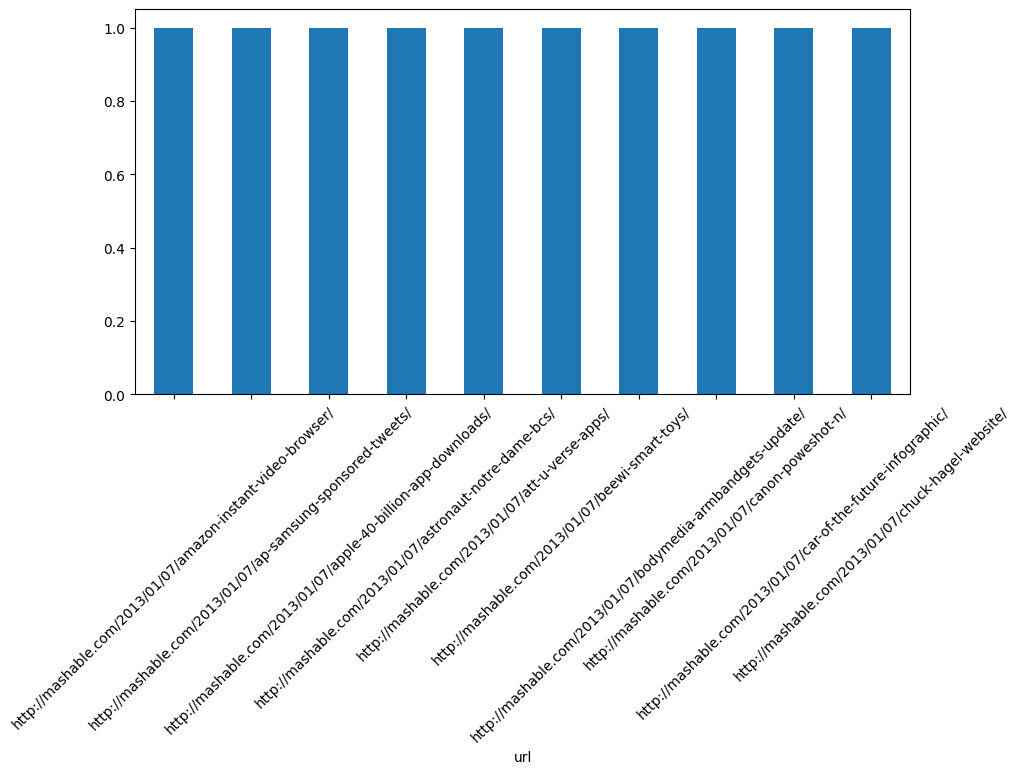

In [169]:
#Countplot
plt.figure(figsize=(10,5))

dataset["url"].value_counts().head(10).plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

#The categorical feature (url) contains a very large number of unique values, so only a subset was visualized for readability.#

#Only one categorical (string) feature (url) was identified in the dataset. The distribution of its values was explored using frequency analysis and countplot visualization.#

Skewness Analysis

In [170]:
skew_values = (dataset.select_dtypes(include="number").skew())
skew_values

timedelta                          0.120504
n_tokens_title                     0.165320
n_tokens_content                   2.945422
n_unique_tokens                  198.655116
n_non_stop_words                 198.792445
n_non_stop_unique_tokens         198.443294
num_hrefs                          4.013495
num_self_hrefs                     5.172751
num_imgs                           3.946596
num_videos                         7.019533
average_token_length              -4.576012
num_keywords                      -0.147251
data_channel_is_lifestyle          3.993019
data_channel_is_entertainment      1.683585
data_channel_is_bus                1.876870
data_channel_is_socmed             3.758880
data_channel_is_tech               1.619976
data_channel_is_world              1.405169
kw_min_min                         2.374947
kw_max_min                        35.328434
kw_avg_min                        31.306108
kw_min_max                        10.386372
kw_max_max                      

In [171]:
skew_values.sort_values(ascending=False).head(10)


n_non_stop_words              198.792445
n_unique_tokens               198.655116
n_non_stop_unique_tokens      198.443294
kw_max_min                     35.328434
shares                         33.963885
kw_avg_min                     31.306108
self_reference_min_shares      26.264364
self_reference_avg_sharess     17.914093
kw_max_avg                     16.411670
self_reference_max_shares      13.870849
dtype: float64

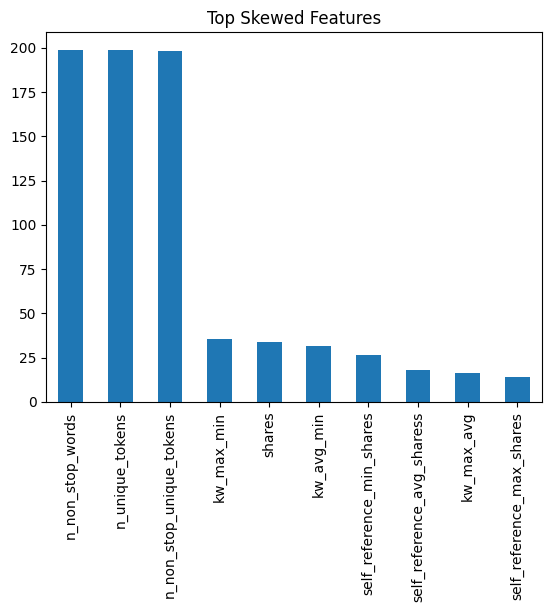

In [172]:
#Bar Chart
skew_values.sort_values( ascending=False).head(10).plot( kind="bar")
plt.title("Top Skewed Features")
plt.show()

#Several numerical features show high skewness.#


Pairplot Analysis

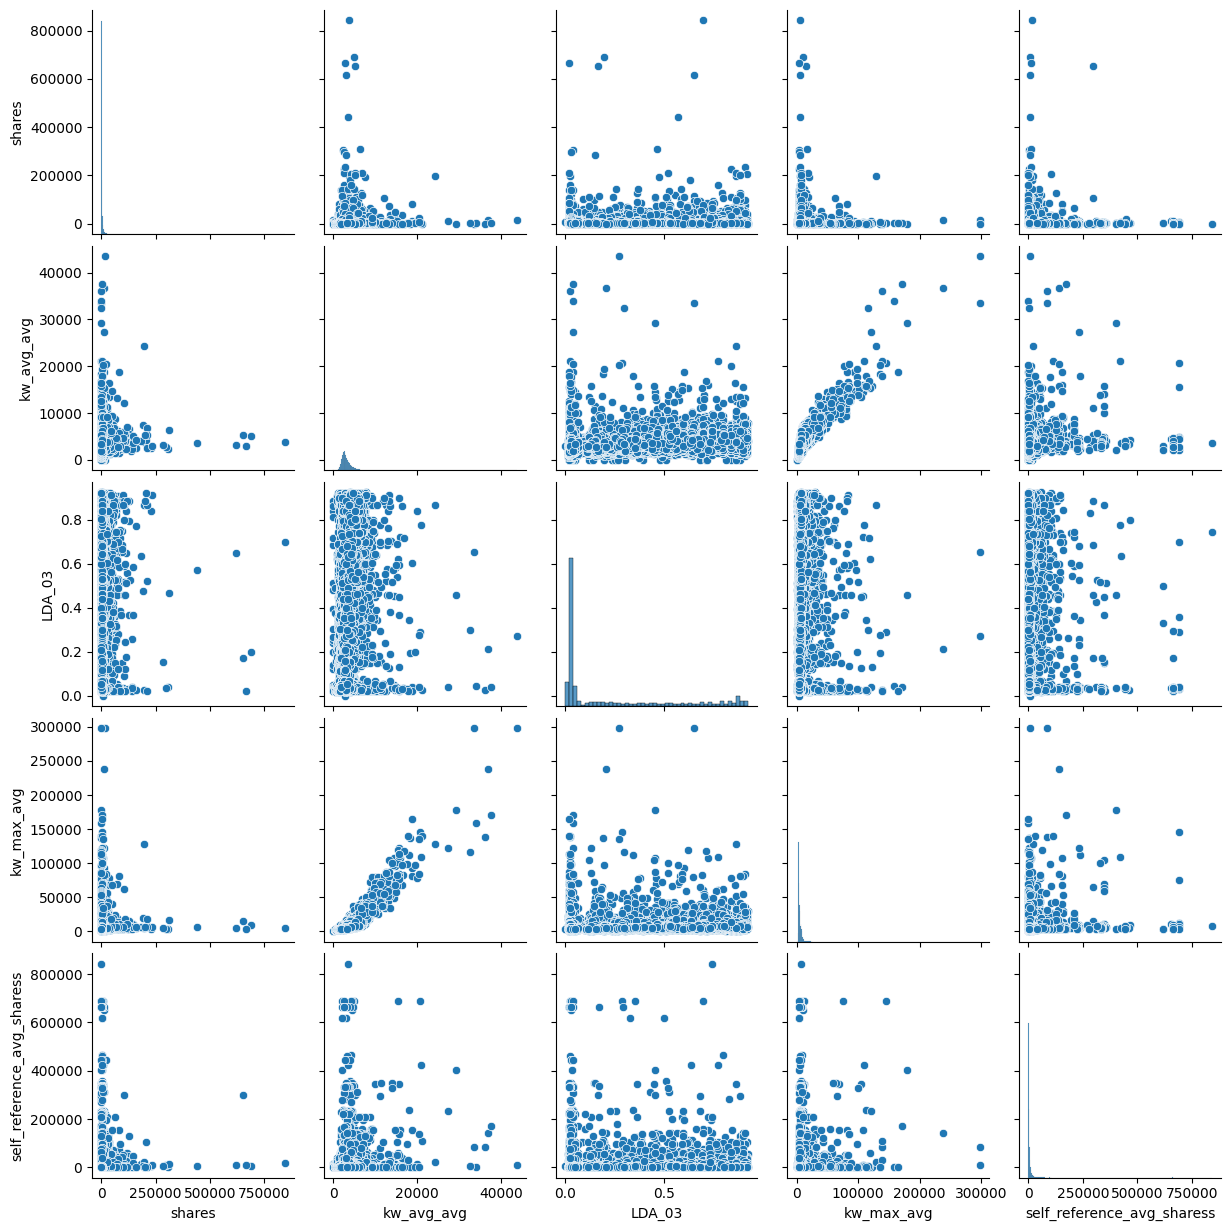

In [173]:
selected_cols =[
"shares",
"kw_avg_avg",
"LDA_03",
"kw_max_avg",
"self_reference_avg_sharess"]
#Pairplot
sns.pairplot(dataset[selected_cols])
plt.show()

#Most selected features show weak relationships with shares.
Some outliers and non-linear patterns were observed.#

# Finally
After exploring the dataset, no missing values or duplicate rows were found.
The target variable (shares) appears highly skewed and contains outliers.
Most features showed weak relationships with the target, which suggests that prediction may depend on combining multiple features rather than a single feature.